# Импорт библиотек

In [101]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import selectKBest, selectRFE, drawSelection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, RFE
from sklearn.decomposition import PCA
from scipy.stats import randint
import xgboost as xgb

# Считывание данных

In [103]:
df = pd.read_csv('data/processed.csv')
df.shape

(1001, 193)

# Очистка таргета от выбросов

In [105]:
df = df[df['IC50, mM'] < 2000]

# Подготовка данных для эксперемента

In [107]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['IC50, mM'].apply(lambda v: 1 if v >= df['IC50, mM'].median() else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (796, 190), (796,)
Test dataset size: (200, 190), (200,)


# Эксперемент с различными моделями

## Логистическая регрессия

In [110]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.685
Confusion Matrix:
[[71 37]
 [26 66]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       108
           1       0.64      0.72      0.68        92

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.68       200
weighted avg       0.69      0.69      0.69       200



## Метод опорных векторов

In [112]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.7
Confusion Matrix:
[[72 36]
 [24 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       108
           1       0.65      0.74      0.69        92

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.71      0.70      0.70       200



In [113]:
model = SVC(kernel='poly')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.65
Confusion Matrix:
[[63 45]
 [25 67]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.58      0.64       108
           1       0.60      0.73      0.66        92

    accuracy                           0.65       200
   macro avg       0.66      0.66      0.65       200
weighted avg       0.66      0.65      0.65       200



In [114]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.68
Confusion Matrix:
[[68 40]
 [24 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.63      0.68       108
           1       0.63      0.74      0.68        92

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.69      0.68      0.68       200



## Метод k-ближайших соседей

In [116]:
k = 3  # Количество ближайших соседей
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.73
Confusion Matrix:
[[76 32]
 [22 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74       108
           1       0.69      0.76      0.72        92

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



In [141]:
k = 6  # Количество ближайших соседей
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.715
Confusion Matrix:
[[87 21]
 [36 56]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.81      0.75       108
           1       0.73      0.61      0.66        92

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



## Деревья решений

In [118]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.675
Confusion Matrix:
[[74 34]
 [31 61]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       108
           1       0.64      0.66      0.65        92

    accuracy                           0.68       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.68      0.68      0.68       200



## Случайный лес

In [120]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.715
Confusion Matrix:
[[77 31]
 [26 66]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       108
           1       0.68      0.72      0.70        92

    accuracy                           0.71       200
   macro avg       0.71      0.72      0.71       200
weighted avg       0.72      0.71      0.72       200



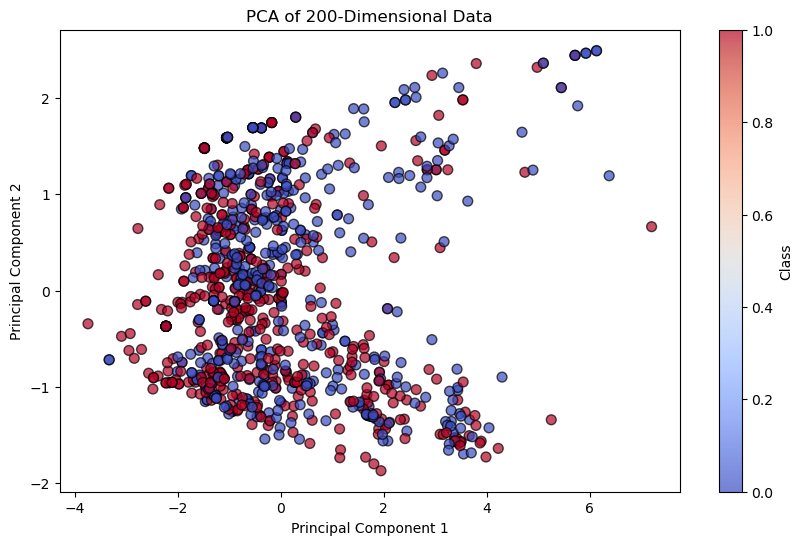

In [121]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализируем данные
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50, alpha=0.7)
plt.title('PCA of 200-Dimensional Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class')
plt.show()

Визуализация высокоразмерных данных после снижения размерности имеет несколько целей и преимуществ:

1. **Интуитивное понимание данных**: Визуализация позволяет исследователям и аналитикам получить интуитивное представление о структуре данных. Это может помочь выявить кластеры, группы или аномалии, которые трудно обнаружить в высокоразмерном пространстве.

2. **Оценка разделимости классов**: Визуализация может показать, насколько хорошо классы разделены в данных. Если классы четко разделены в низкоразмерном пространстве, это может свидетельствовать о том, что модель классификации будет работать хорошо.

3. **Выявление выбросов и аномалий**: Визуализация может помочь обнаружить выбросы или аномалии, которые могут повлиять на производительность модели. Это может быть полезно для дальнейшей очистки данных.

4. **Понимание структуры данных**: Методы снижения размерности, такие как PCA, t-SNE и UMAP, могут выявить скрытые структуры в данных, такие как нелинейные зависимости или многомерные кластеры, которые трудно обнаружить в исходном пространстве.

5. **Коммуникация результатов**: Визуализация данных является мощным инструментом для представления результатов и идей широкой аудитории, включая тех, кто может не иметь глубоких знаний в области машинного обучения. Графики и диаграммы могут сделать сложные концепции более доступными.

6. **Диагностика модели**: Визуализация может помочь в диагностике модели, например, в выявлении случаев, когда модель может ошибаться, и в понимании причин этих ошибок.

Важно отметить, что визуализация после снижения размерности — это лишь приближение, и она может потерять некоторые детали, присутствующие в исходных данных. Однако она остается ценным инструментом для предварительного анализа и интерпретации данных.

## Градиентный бустинг

In [124]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.72
Confusion Matrix:
[[80 28]
 [28 64]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       108
           1       0.70      0.70      0.70        92

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200



## Наивный байесовский классификатор

In [126]:
# Создаем и обучаем модель Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.61
Confusion Matrix:
[[94 14]
 [64 28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.87      0.71       108
           1       0.67      0.30      0.42        92

    accuracy                           0.61       200
   macro avg       0.63      0.59      0.56       200
weighted avg       0.63      0.61      0.57       200



# Фильтрация признаков

# Подбор гиперпараметров

# Лучшая модель

In [4]:
info_gain = mutual_info_classif(X, y)

info_gain_df = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': info_gain
})

info_gain_df = info_gain_df.sort_values(by='Information Gain', ascending=False)

info_gain_df

,Feature,Information Gain
9,MinAbsPartialCharge,0.154050
7,MinPartialCharge,0.149591
74,TPSA,0.139342
6,MaxPartialCharge,0.137836
59,SMR_VSA5,0.130377
...,...,...
122,fr_C_O,0.000000
49,PEOE_VSA5,0.000000
149,fr_hdrzine,0.000000
110,NumSaturatedRings,0.000000


In [ ]:

# Создаем пример данных
data = {
    'Feature1': [2, 4, 5, 7, 9, 1, 3, 6, 8, 10],
    'Feature2': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'Feature3': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'Admitted': [0, 1, 0, 1, 1, 0, 0, 1, 1, 1]
}

# Преобразуем данные в DataFrame
df = pd.DataFrame(data)

# Разделяем данные на признаки и целевую переменную
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Admitted']

# Применяем метод фильтрации (SelectKBest с тестом хи-квадрат)
selector = SelectKBest(score_func=chi2, k=2)  # Выбираем 2 лучших признака
X_new = selector.fit_transform(X, y)

# Выводим результаты отбора признаков
print("Scores for each feature:", selector.scores_)
print("Selected features:", X.columns[selector.get_support()])

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

# Создаем и обучаем модель логистической регрессии
model = LogisticRegression()
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

In [ ]:

# Создаем пример данных
data = {
    'Feature1': [2, 4, 5, 7, 9, 1, 3, 6, 8, 10],
    'Feature2': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'Feature3': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'Admitted': [0, 1, 0, 1, 1, 0, 0, 1, 1, 1]
}

# Преобразуем данные в DataFrame
df = pd.DataFrame(data)

# Разделяем данные на признаки и целевую переменную
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Admitted']

# Создаем модель логистической регрессии
model = LogisticRegression()

# Применяем RFE для выбора признаков
selector = RFE(estimator=model, n_features_to_select=2)  # Выбираем 2 лучших признака
selector = selector.fit(X, y)

# Выводим результаты отбора признаков
print("Selected features:", X.columns[selector.support_])
print("Feature ranking:", selector.ranking_)

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X[X.columns[selector.support_]], y, test_size=0.3, random_state=42)

# Обучаем модель на выбранных признаках
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

In [ ]:

# Создаем пример данных
data = {
    'Feature1': [2, 4, 5, 7, 9, 1, 3, 6, 8, 10],
    'Feature2': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'Feature3': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'Admitted': [0, 1, 0, 1, 1, 0, 0, 1, 1, 1]
}

# Преобразуем данные в DataFrame
df = pd.DataFrame(data)

# Разделяем данные на признаки и целевую переменную
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Admitted']

# Применяем метод фильтрации (SelectKBest с mutual_info_classif)
selector = SelectKBest(score_func=mutual_info_classif, k=2)  # Выбираем 2 лучших признака
X_new = selector.fit_transform(X, y)

# Выводим результаты отбора признаков
print("Scores for each feature:", selector.scores_)
print("Selected features:", X.columns[selector.get_support()])

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

# Создаем и обучаем модель логистической регрессии
model = LogisticRegression()
model.fit(X_train, y_train)

# Делаем прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Оцениваем модель
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

При бинарной классификации существует несколько ключевых метрик, которые помогают оценить качество модели. Вот основные из них:

1. **Accuracy (Точность)**: Доля правильных предсказаний от общего числа предсказаний. Это простая и часто используемая метрика, но она может быть неинформативной в случае несбалансированных классов.

   \[
   \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
   \]

2. **Precision (Точность, или положительная прогностическая ценность)**: Доля истинно положительных предсказаний от всех предсказанных положительных.

   \[
   \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
   \]

3. **Recall (Полнота, или чувствительность)**: Доля истинно положительных предсказаний от всех фактических положительных случаев.

   \[
   \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
   \]

4. **F1-Score**: Гармоническое среднее между точностью и полнотой. Эта метрика полезна, когда важно найти баланс между точностью и полнотой.

   \[
   \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
   \]

5. **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**: Площадь под кривой ошибок приемника. Эта метрика показывает, насколько хорошо модель способна различать классы. Значение 0.5 соответствует случайному угадыванию, а 1.0 — идеальной модели.

6. **Confusion Matrix (Матрица ошибок)**: Таблица, которая позволяет визуализировать производительность алгоритма классификации. Она показывает количество истинно положительных (TP), истинно отрицательных (TN), ложно положительных (FP) и ложно отрицательных (FN) предсказаний.

Каждая из этих метрик имеет свои сильные и слабые стороны, и выбор метрики зависит от конкретной задачи и важности различных типов ошибок. Например, в медицинской диагностике может быть критически важна высокая полнота (recall), чтобы минимизировать количество пропущенных положительных случаев.